<a href="https://colab.research.google.com/github/PovSobek/Manipuladores/blob/main/E02_inverse_kinematics_recursive.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# E02- Inverse kinematics.

This example shows how to solve the Inverse Kinematic Problem (IK) of open chain robot using a recursive method.

---



After review the basic concepts, you will have to solve the Inverse Kinematics
of your selected robot at the section "Example with my robot"

```
# Exercise:
After review the basic concepts, you will have to solve the Inverse Kinematics
of your selected robot at the section "Example with my robot"
```

In [ ]:
#Funciones auxilares
'''
funciones importadas de Modern Robotics de Frank C. Park
https://github.com/NxRLab/ModernRobotics/tree/master/packages/Python
copiadas del fichero core.py

'''

import math #para poder usar math.pi
import numpy as np

def NearZero(z):
  return abs(z) < 1e-6

def se3ToVec(se3mat):
  return np.r_[[se3mat[2][1], se3mat[0][2], se3mat[1][0]],
            [se3mat[0][3], se3mat[1][3], se3mat[2][3]]]

def MatrixLog6(T):
  R, p = TransToRp(T)
  omgmat = MatrixLog3(R)
  if np.array_equal(omgmat, np.zeros((3, 3))):
      return np.r_[np.c_[np.zeros((3, 3)),
                        [T[0][3], T[1][3], T[2][3]]],
                 [[0, 0, 0, 0]]]
  else:
      theta = np.arccos((np.trace(R) - 1) / 2.0)
      return np.r_[np.c_[omgmat,
                  np.dot(np.eye(3) - omgmat / 2.0 \
                   + (1.0 / theta - 1.0 / np.tan(theta / 2.0) / 2) \
                     * np.dot(omgmat,omgmat) / theta,[T[0][3],
                                   T[1][3],
                                   T[2][3]])],
                     [[0, 0, 0, 0]]]

def TransToRp(T):
    T = np.array(T)
    return T[0: 3, 0: 3], T[0: 3, 3]

def MatrixLog3(R):
    acosinput = (np.trace(R) - 1) / 2.0
    if acosinput >= 1:
        return np.zeros((3, 3))
    elif acosinput <= -1:
        if not NearZero(1 + R[2][2]):
            omg = (1.0 / np.sqrt(2 * (1 + R[2][2]))) \
                  * np.array([R[0][2], R[1][2], 1 + R[2][2]])
        elif not NearZero(1 + R[1][1]):
            omg = (1.0 / np.sqrt(2 * (1 + R[1][1]))) \
                  * np.array([R[0][1], 1 + R[1][1], R[2][1]])
        else:
            omg = (1.0 / np.sqrt(2 * (1 + R[0][0]))) \
                  * np.array([1 + R[0][0], R[1][0], R[2][0]])
        return VecToso3(np.pi * omg)
    else:
        theta = np.arccos(acosinput)
        return theta / 2.0 / np.sin(theta) * (R - np.array(R).T)

def VecToso3(omg):
    return np.array([[0,      -omg[2],  omg[1]],
                     [omg[2],       0, -omg[0]],
                     [-omg[1], omg[0],       0]])

def TransInv(T):
    R, p = TransToRp(T)
    Rt = np.array(R).T
    return np.r_[np.c_[Rt, -np.dot(Rt, p)], [[0, 0, 0, 1]]]

def MatrixExp6(se3mat):
    se3mat = np.array(se3mat)
    omgtheta = so3ToVec(se3mat[0: 3, 0: 3])
    if NearZero(np.linalg.norm(omgtheta)):
        return np.r_[np.c_[np.eye(3), se3mat[0: 3, 3]], [[0, 0, 0, 1]]]
    else:
        theta = AxisAng3(omgtheta)[1]
        omgmat = se3mat[0: 3, 0: 3] / theta
        return np.r_[np.c_[MatrixExp3(se3mat[0: 3, 0: 3]),
                           np.dot(np.eye(3) * theta \
                                  + (1 - np.cos(theta)) * omgmat \
                                  + (theta - np.sin(theta)) \
                                    * np.dot(omgmat,omgmat),
                                  se3mat[0: 3, 3]) / theta],
                     [[0, 0, 0, 1]]]

def VecTose3(V):
    return np.r_[np.c_[VecToso3([V[0], V[1], V[2]]), [V[3], V[4], V[5]]],
                 np.zeros((1, 4))]


def JacobianSpace(Slist, thetalist):
    #Js = np.array(Slist).copy().astype(np.float) #deprecated el uso de np.float
    Js = np.array(Slist).copy().astype(float)
    T = np.eye(4)
    for i in range(1, len(thetalist)):
        T = np.dot(T, MatrixExp6(VecTose3(np.array(Slist)[:, i - 1] \
                                * thetalist[i - 1])))
        Js[:, i] = np.dot(Adjoint(T), np.array(Slist)[:, i])
    return Js

def Adjoint(T):
    R, p = TransToRp(T)
    return np.r_[np.c_[R, np.zeros((3, 3))],
                 np.c_[np.dot(VecToso3(p), R), R]]

def so3ToVec(so3mat):
    return np.array([so3mat[2][1], so3mat[0][2], so3mat[1][0]])

def AxisAng3(expc3):
    return (Normalize(expc3), np.linalg.norm(expc3))

def Normalize(V):
    return V / np.linalg.norm(V)

def MatrixExp3(so3mat):
    omgtheta = so3ToVec(so3mat)
    if NearZero(np.linalg.norm(omgtheta)):
        return np.eye(3)
    else:
        theta = AxisAng3(omgtheta)[1]
        omgmat = so3mat / theta
        return np.eye(3) + np.sin(theta) * omgmat \
               + (1 - np.cos(theta)) * np.dot(omgmat, omgmat)

def joint2twist(Axis, Point, JointType):
  if JointType == 'rot':
    aux = -np.cross(Axis, Point)
    twist = np.concatenate((aux, Axis), axis=0)
  elif JointType == 'tra':
    aux2 = [0, 0, 0]
    twist = np.concatenate((Axis, aux2), axis=0)
  else:
    twist = np.array([0, 0, 0, 0, 0, 0])
  return twist


In [ ]:
#funciones para la cinemática en space coordinates

def FKinSpace(M, Slist, thetalist):
    """Computes forward kinematics in the space frame for an open chain robot
    :param M: The home configuration (position and orientation) of the end-
              effector
    :param Slist: The joint screw axes in the space frame when the
                  manipulator is at the home position, in the format of a
                  matrix with axes as the columns
    :param thetalist: A list of joint coordinates
    :return: A homogeneous transformation matrix representing the end-
             effector frame when the joints are at the specified coordinates
             (i.t.o Space Frame)
    Example Input:
        M = np.array([[-1, 0,  0, 0],
                      [ 0, 1,  0, 6],
                      [ 0, 0, -1, 2],
                      [ 0, 0,  0, 1]])
        Slist = np.array([[0, 0,  1,  4, 0,    0],
                          [0, 0,  0,  0, 1,    0],
                          [0, 0, -1, -6, 0, -0.1]]).T
        thetalist = np.array([np.pi / 2.0, 3, np.pi])
    Output:
        np.array([[0, 1,  0,         -5],
                  [1, 0,  0,          4],
                  [0, 0, -1, 1.68584073],
                  [0, 0,  0,          1]])
    """
    T = np.array(M)
    for i in range(len(thetalist) - 1, -1, -1):
        T = np.dot(MatrixExp6(VecTose3(np.array(Slist)[:, i] \
                                       * thetalist[i])), T)
    return T


def IKinSpace(Slist, M, T, thetalist0, eomg, ev):
    """Computes inverse kinematics in the space frame for an open chain robot
    :param Slist: The joint screw axes in the space frame when the
                  manipulator is at the home position, in the format of a
                  matrix with axes as the columns
    :param M: The home configuration of the end-effector
    :param T: The desired end-effector configuration Tsd
    :param thetalist0: An initial guess of joint angles that are close to
                       satisfying Tsd
    :param eomg: A small positive tolerance on the end-effector orientation
                 error. The returned joint angles must give an end-effector
                 orientation error less than eomg
    :param ev: A small positive tolerance on the end-effector linear position
               error. The returned joint angles must give an end-effector
               position error less than ev
    :return thetalist: Joint angles that achieve T within the specified
                       tolerances,
    :return success: A logical value where TRUE means that the function found
                     a solution and FALSE means that it ran through the set
                     number of maximum iterations without finding a solution
                     within the tolerances eomg and ev.
    Uses an iterative Newton-Raphson root-finding method.
    The maximum number of iterations before the algorithm is terminated has
    been hardcoded in as a variable called maxiterations. It is set to 20 at
    the start of the function, but can be changed if needed.
    Example Input:
        Slist = np.array([[0, 0,  1,  4, 0,    0],
                          [0, 0,  0,  0, 1,    0],
                          [0, 0, -1, -6, 0, -0.1]]).T
        M = np.array([[-1, 0,  0, 0],
                      [ 0, 1,  0, 6],
                      [ 0, 0, -1, 2],
                      [ 0, 0,  0, 1]])
        T = np.array([[0, 1,  0,     -5],
                      [1, 0,  0,      4],
                      [0, 0, -1, 1.6858],
                      [0, 0,  0,      1]])
        thetalist0 = np.array([1.5, 2.5, 3])
        eomg = 0.01
        ev = 0.001
    Output:
        (np.array([ 1.57073783,  2.99966384,  3.1415342 ]), True)
    """
    thetalist = np.array(thetalist0).copy()
    i = 0
    maxiterations = 20
    Tsb = FKinSpace(M,Slist, thetalist)
    Vs = np.dot(Adjoint(Tsb), \
                se3ToVec(MatrixLog6(np.dot(TransInv(Tsb), T))))
    err = np.linalg.norm([Vs[0], Vs[1], Vs[2]]) > eomg \
          or np.linalg.norm([Vs[3], Vs[4], Vs[5]]) > ev
    while err and i < maxiterations:
        thetalist = thetalist \
                    + np.dot(np.linalg.pinv(JacobianSpace(Slist, \
                                                          thetalist)), Vs)
        i = i + 1
        Tsb = FKinSpace(M, Slist, thetalist)
        Vs = np.dot(Adjoint(Tsb), \
                    se3ToVec(MatrixLog6(np.dot(TransInv(Tsb), T))))
        err = np.linalg.norm([Vs[0], Vs[1], Vs[2]]) > eomg \
              or np.linalg.norm([Vs[3], Vs[4], Vs[5]]) > ev
    return (thetalist, not err)


#Example 4DOF Cilindrical Robot

![texto alternativo](https://medicalrobotics.umh.es/files/2022/03/4gdlScrews2.jpg)



\begin{array}{|c|c|c|}
\hline
\textbf{Eslabón} & \mathbf{s} & \mathbf{r_o} \\
 \hline
1 & (0,0,1) & (0,0,0) \\
2 & (0,0,1) & (0,0,0) \\
3 & (0,1,0) & (-a_2,0,l_1) \\
4 & (0,1,0) & (-a_2,l_4,l_1) \\
\hline
\end{array}


Steps:

* Define the robot and compute the twists
* Compute the FK
* Compute the IK and check


In [ ]:
# para el calculo del tiempo de computo
import time
inicio = time.time()

# STEP 1. definicion del robot
p1 = [0,0,0]
p2 = [0., 0., 0.]
p3 = [-0.1, 0, 0.4]
p4 = [-0.1, 0.2, 0.4]

Axis1 = [0,0,1]
Axis2 = [0,0,1]
Axis3 = [0,1,0]
Axis4 = [0,1,0]

# calculo de los twist
twist1 = joint2twist (Axis1, p1, 'rot')
twist2 = joint2twist (Axis2, p2, 'tra')
twist3 = joint2twist (Axis3, p3, 'tra')
twist4 = joint2twist (Axis4, p4, 'rot')

# twist del robot (por columnas) INVERTIDOS !!
Slist = np.array([[twist1[3], twist1[4], twist1[5], twist1[0], twist1[1],   twist1[2]],
                  [twist2[3], twist2[4], twist2[5], twist2[0], twist2[1],   twist2[2]],
                  [twist3[3], twist3[4], twist3[5], twist3[0], twist3[1],   twist3[2]],
                  [twist4[3], twist4[4], twist4[5], twist4[0], twist4[1],   twist4[2]]]).T

# parametros para la IK recursiva
## The home configuration of the end-effector
Hst0 = np.array([[1, 0,  0, p4[0]],
              [ 0, 0,  -1, p4[1]],
              [ 0, 1, 0, p4[2]],
              [ 0, 0,  0, 1]])

## estimacion incial de la solucion
thetalist0 = np.array([0, 0, 0, 0])
## valores error
eomg = 0.001
ev = 0.0001

# The desired end-effector configuration
thetalist = np.array([math.pi/4, 0.3, 0.05, 0])
print ("Desired joint coordinates (4 dof) (recursive): \n", thetalist)
print("--"*20)
# STEP 2. calculo de la FK
FK = FKinSpace(Hst0, Slist, thetalist)
print ("FK (4dof)=  \n", FK)
'''T = np.array([[1, 0,  0, p4[0]],
              [ 0, 0,  -1, p4[1]],
              [ 0, 1, 0, p4[2]+0.2],
              [ 0, 0,  0, 1]])'''

# STEP 3. calculo de la IK
IK = IKinSpace(Slist, Hst0, FK, thetalist0, eomg, ev)
print ("IK (4 dof) (recursive): \n", IK[0])
print("--"*20)
final = time.time()
print("tiempo de computo  =", final-inicio)

# <font size="5" color="green"> Homework </font>


## <font size="4" color="green"> Ejemplo del robot IRB120  6 GDL </font>

#Ejemplo de Robot
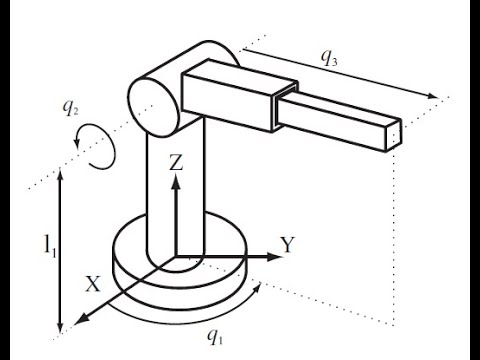

In [ ]:

inicio = time.time()

# STEP 1. Definición del robot (R–R–P)
# l1 es la altura de la base al segundo eje, como se ve en la imagen
l1 = 0.4

# Puntos sobre los ejes en configuración home (q1=0, q2=0, q3=0)
po = [0., 0., 0.]     # Eje 1 (base) pasa por el origen {S}
pk = [0., 0., l1]     # Eje 2 (rotación Y) está en z=l1
pr = [0., 0., l1]     # Eje 3 (prismático) inicia en z=l1

# Ejes de las articulaciones (definidos en el frame base {S})
Axis1 = [0., 0., 1.]  # q1: rotación sobre Z (art. 1)
Axis2 = [0., 1., 0.]  # q2: rotación sobre Y (art. 2)
Axis3 = [1., 0., 0.]  # q3: traslación sobre X (art. 3)

# Cálculo de los twists (Ejes de Tornillo)
# Se usa la función global 'joint2twist' que devuelve (v, w)
twist1_vw = joint2twist(Axis1, po, 'rot') # Eje 1 (Rotación)
twist2_vw = joint2twist(Axis2, pk, 'rot') # Eje 2 (Rotación)
twist3_vw = joint2twist(Axis3, pr, 'tra') # Eje 3 (Traslación)

# Slist (columnas) debe estar en formato (w, v)
# La función 'joint2twist' global devuelve (v, w)
# Por eso ensamblamos Slist como [w, v] usando los índices
Slist = np.array([
    [twist1_vw[3], twist1_vw[4], twist1_vw[5], twist1_vw[0], twist1_vw[1], twist1_vw[2]],
    [twist2_vw[3], twist2_vw[4], twist2_vw[5], twist2_vw[0], twist2_vw[1], twist2_vw[2]],
    [twist3_vw[3], twist3_vw[4], twist3_vw[5], twist3_vw[0], twist3_vw[1], twist3_vw[2]]
]).T

# STEP 2. Configuración "home" del efector final (M o Hst0)
# Esta es la pose del efector cuando q1=q2=q3=0
Hst0 = np.array([
    [1, 0, 0, 0],   # R = Identidad
    [0, 1, 0, 0],
    [0, 0, 1, l1],  # p = (0, 0, l1)
    [0, 0, 0, 1]
])

# STEP 3. Cálculo de la IK

# Estimación inicial para el algoritmo iterativo
thetalist0 = np.array([0., 0., 0.])

# Tolerancias de error
eomg = 0.01  # Error de orientación
ev = 0.001   # Error de posición

# --- PRUEBA ---
# 1. Definimos una pose objetivo (usando los valores de la imagen)
#    q1 = 45 deg, q2 = 30 deg, q3 = 0.3 m
thetalist_deseada = np.array([np.deg2rad(45), np.deg2rad(30), 0.3])
print("Valores articulares deseados (de la imagen): \n", thetalist_deseada)
print("--"*20)

# 2. Calculamos la FK para encontrar la pose (T) que generan esos ángulos
FK_objetivo = FKinSpace(Hst0, Slist, thetalist_deseada)
print("Pose objetivo (T) calculada con FK: \n", FK_objetivo)
print("--"*20)

# 3. Calculamos la IK para encontrar los ángulos que
#    nos lleven a la pose 'FK_objetivo'.
(IK_calculada, success) = IKinSpace(Slist, Hst0, FK_objetivo, thetalist0, eomg, ev)

print("Valores articulares encontrados por IK: \n", IK_calculada)
print("Solución encontrada con éxito: ", success)
print("--"*20)

final = time.time()
print("Tiempo de cómputo =", final - inicio)

In [ ]:
# @title Solución IRB120
# para el calculo del tiempo de computo
import time
inicio = time.time()

# STEP 1. definicion del robot
po = [0,0,0]
pk = [0., 0, 0.290]
pr = [0., 0, 0.560]
pf = [0.302, 0., 0.630]
pp = [0.302, 0., 0.470]
Axis1 = [0,0,1]
Axis2 = [0,1,0]
Axis3 = [0,1,0]
Axis4 = [1,0,0]
Axis5 = [0,1,0]
Axis6 = [0,0,-1]

# calculo de los twist
twist1 = joint2twist (Axis1, po, 'rot')
twist2 = joint2twist (Axis2, pk, 'rot')
twist3 = joint2twist (Axis3, pr, 'rot')
twist4 = joint2twist (Axis4, pf, 'rot')
twist5 = joint2twist (Axis5, pf, 'rot')
twist6 = joint2twist (Axis6, pf, 'rot')

# twist del robot (por columnas) INVERTIDOS !!
Slist = np.array([[twist1[3], twist1[4], twist1[5], twist1[0], twist1[1],   twist1[2]],
                  [twist2[3], twist2[4], twist2[5], twist2[0], twist2[1],   twist2[2]],
                  [twist3[3], twist3[4], twist3[5], twist3[0], twist3[1],   twist3[2]],
                  [twist4[3], twist4[4], twist4[5], twist4[0], twist4[1],   twist4[2]],
                  [twist5[3], twist5[4], twist5[5], twist5[0], twist5[1],   twist5[2]],
                  [twist6[3], twist6[4], twist6[5], twist6[0], twist6[1],   twist6[2]]]).T

# parametros para la IK recursiva
## The home configuration of the end-effector
Hst0 = np.array([[1, 0,  0, pp[0]],
              [ 0, 0,  -1, pp[1]],
              [ 0, 1, 0, pp[2]],
              [ 0, 0,  0, 1]])

## estimacion incial de la solucion
thetalist0 = np.array([0, 0.8, 0.0, 0, 0, 0])
## valores error
eomg = 0.01
ev = 0.001

# The desired end-effector configuration
thetalist = np.array([0.8, 0.5, 0.0, 0.0, 0.0, 0.0])
print ("Desired joint coordinates (6 dof) (recursive): \n", thetalist)
print("--"*20)
# STEP 2. calculo de la FK
FK = FKinSpace(Hst0, Slist, thetalist)
print ("FK (6dof)=  \n", FK)


# STEP 3. calculo de la IK
IK = IKinSpace(Slist, Hst0, FK, thetalist0, eomg, ev)
print ("IK (6 dof) (recursive): \n", IK[0])
print("--"*20)
final = time.time()
print("tiempo de computo  =", final-inicio)